Cell 1: Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

print("✅ Ready to analyze Reddit data!")
print("💬 Let's see what Reddit communities are saying...")

✅ Ready to analyze Reddit data!
💬 Let's see what Reddit communities are saying...


Cell 2: Load Reddit Dataset

In [2]:
import json
import pandas as pd

# Load JSON file
with open('v5_reddit_post_engagement.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f"💬 Loaded {len(raw_data):,} Reddit records (raw JSON)")

# Normalize JSON → DataFrame
df_reddit = pd.json_normalize(raw_data)

print(f"📊 Dataset has {len(df_reddit.columns)} columns")
df_reddit.head(3)

💬 Loaded 1,797 Reddit records (raw JSON)
📊 Dataset has 1867 columns


,_id,kind,symbol,username,entityId,entityType,crawledAt,data.approved_at_utc,data.subreddit,data.selftext,...,data.media_metadata.iltr2rjeag7f1.s.u,data.media_metadata.iltr2rjeag7f1.id,data.media_metadata.5kzwb7lanmbf1.status,data.media_metadata.5kzwb7lanmbf1.e,data.media_metadata.5kzwb7lanmbf1.m,data.media_metadata.5kzwb7lanmbf1.p,data.media_metadata.5kzwb7lanmbf1.s.y,data.media_metadata.5kzwb7lanmbf1.s.x,data.media_metadata.5kzwb7lanmbf1.s.u,data.media_metadata.5kzwb7lanmbf1.id
0,691ad3ffb3ddcc47a8000094,t3,MIM,Puzzleheaded_Way_962,67b761f900bd4e4006af8dbe,official,2025-11-17T07:51:14.154Z,,SpellToken,Love to see this community growing like it is!...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,691ad3ffb3ddcc47a8000093,t3,MIM,Mrkornv,67b761f900bd4e4006af8dbe,official,2025-11-17T07:51:14.154Z,,SpellToken,So guys I'm very optimistic on a lot of coins ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,691ad3ffb3ddcc47a8000092,t3,MIM,[deleted],67b761f900bd4e4006af8dbe,official,2025-11-17T07:51:14.154Z,,SpellToken,"Just sold my position, can’t wait to hop back ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 3: Explore Reddit Data

In [3]:
important_columns = {
    'symbol': 'Which currency',
    'data.title': 'Post title',
    'data.ups': 'Upvotes',
    'data.num_comments': 'Number of comments',
    'data.score': 'Reddit score',
    'data.subreddit': 'Which subreddit'
}

print("📋 Reddit Post Information:")
for col, desc in important_columns.items():
    if col in df_reddit.columns:
        print(f"  ✅ {col:25s} - {desc}")
    else:
        print(f"  ❌ {col:25s} - Not available")

print("\n💬 Sample Reddit Post:")
sample = df_reddit.iloc[0]
print(f"Title     : {sample.get('data.title')}")
print(f"Symbol    : {sample.get('symbol')}")
print(f"Upvotes   : {sample.get('data.ups')}")
print(f"Comments  : {sample.get('data.num_comments')}")

📋 Reddit Post Information:
  ✅ symbol                    - Which currency
  ✅ data.title                - Post title
  ✅ data.ups                  - Upvotes
  ✅ data.num_comments         - Number of comments
  ✅ data.score                - Reddit score
  ✅ data.subreddit            - Which subreddit

💬 Sample Reddit Post:
Title     : We are growing!
Symbol    : MIM
Upvotes   : 19
Comments  : 7


Cell 4: 🏆 Most Discussed Currencies

🏆 TOP 10 MOST DISCUSSED ON REDDIT
 1. USDA       - 182 posts
 2. GUSD       - 163 posts
 3. USDC       - 138 posts
 4. RLUSD      - 115 posts
 5. USDT       - 113 posts
 6. KAU        - 109 posts
 7. DAI        - 105 posts
 8. SUSD       - 102 posts
 9. HBD        - 102 posts
10. MIM        - 100 posts


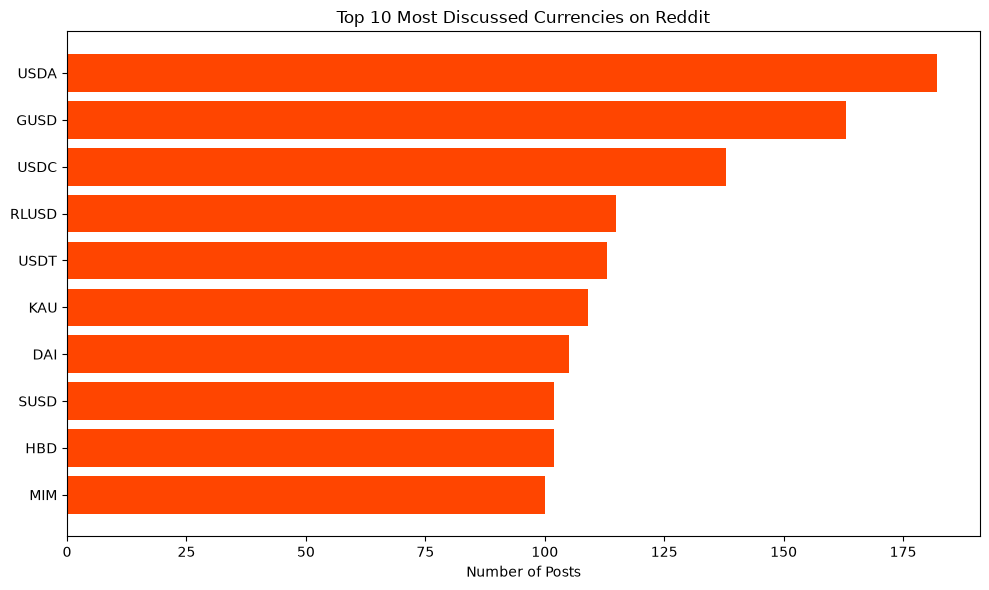

In [4]:
post_counts = df_reddit['symbol'].value_counts().head(10)

print("🏆 TOP 10 MOST DISCUSSED ON REDDIT")
print("=" * 50)

for i, (symbol, count) in enumerate(post_counts.items(), 1):
    print(f"{i:2d}. {symbol:10s} - {count:,} posts")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(post_counts.index, post_counts.values, color='#FF4500')
plt.gca().invert_yaxis()
plt.title("Top 10 Most Discussed Currencies on Reddit")
plt.xlabel("Number of Posts")
plt.tight_layout()
plt.show()

Cell 5: ⬆️ Most Upvoted Currencies

⬆️ TOP 10 BY TOTAL UPVOTES
 1. USDA       - 4,195 upvotes
 2. RLUSD      - 2,290 upvotes
 3. OUSD       - 1,246 upvotes
 4. MIM        - 1,182 upvotes
 5. CUSD       - 976 upvotes
 6. USDC       - 866 upvotes
 7. DAI        - 545 upvotes
 8. TUSD       - 531 upvotes
 9. AMPL       - 518 upvotes
10. USDS       - 514 upvotes


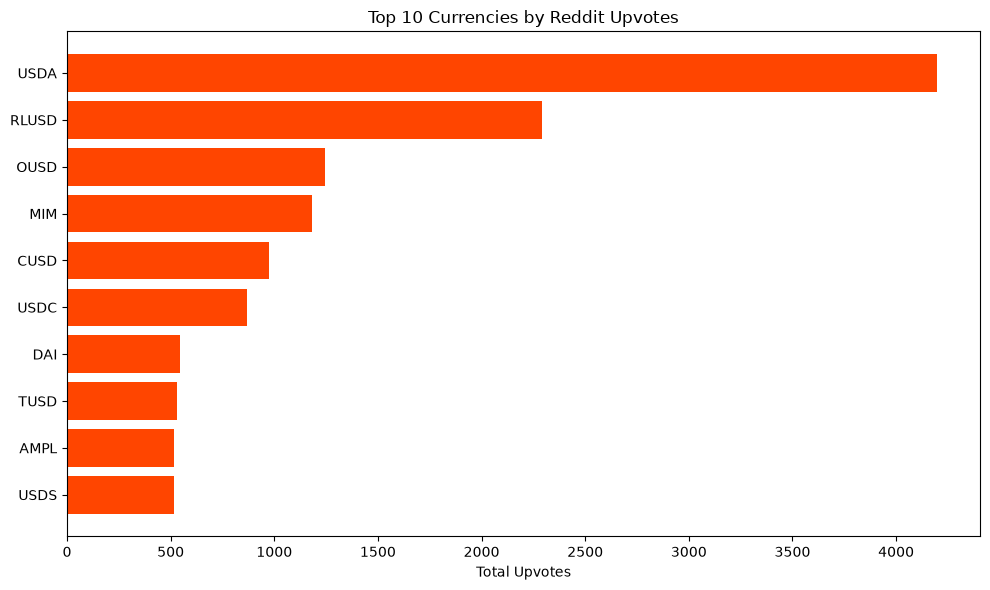

In [5]:
total_upvotes = (
    df_reddit
    .groupby('symbol')['data.ups']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("⬆️ TOP 10 BY TOTAL UPVOTES")
print("=" * 50)

for i, (symbol, ups) in enumerate(total_upvotes.items(), 1):
    print(f"{i:2d}. {symbol:10s} - {int(ups):,} upvotes")

plt.figure(figsize=(10,6))
plt.barh(total_upvotes.index, total_upvotes.values, color='orangered')
plt.gca().invert_yaxis()
plt.title("Top 10 Currencies by Reddit Upvotes")
plt.xlabel("Total Upvotes")
plt.tight_layout()
plt.show()

Cell 6: 💬 Most Commented Currencies

💬 TOP 10 BY TOTAL COMMENTS
 1. USDA       - 2,973 comments
 2. GUSD       - 1,341 comments
 3. RLUSD      - 1,123 comments
 4. MIM        - 895 comments
 5. USDC       - 755 comments
 6. AMPL       - 606 comments
 7. USDS       - 578 comments
 8. DAI        - 459 comments
 9. TUSD       - 412 comments
10. CUSD       - 234 comments


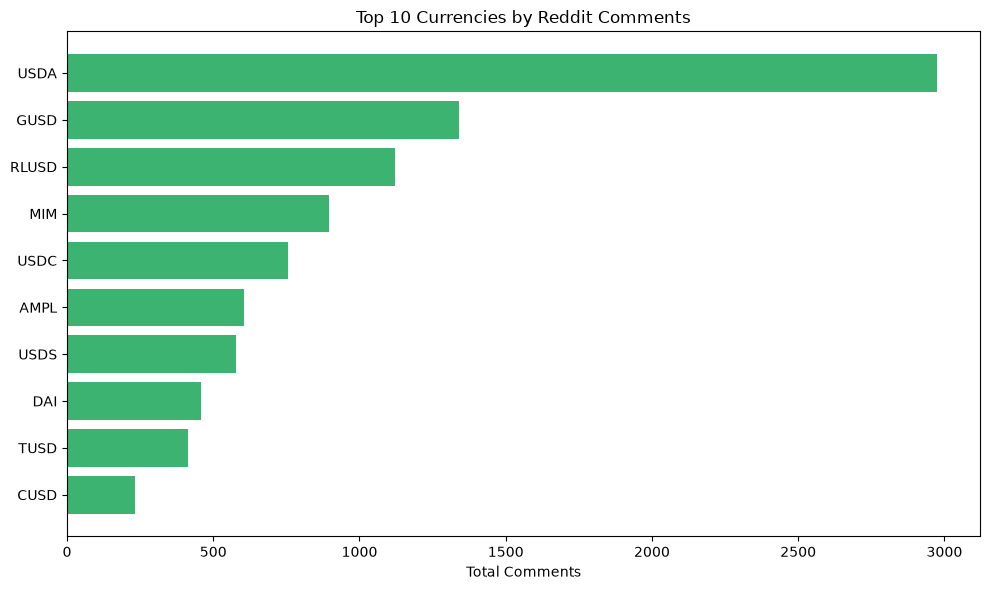

In [6]:
total_comments = (
    df_reddit
    .groupby('symbol')['data.num_comments']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("💬 TOP 10 BY TOTAL COMMENTS")
print("=" * 50)

for i, (symbol, cmt) in enumerate(total_comments.items(), 1):
    print(f"{i:2d}. {symbol:10s} - {int(cmt):,} comments")

plt.figure(figsize=(10,6))
plt.barh(total_comments.index, total_comments.values, color='mediumseagreen')
plt.gca().invert_yaxis()
plt.title("Top 10 Currencies by Reddit Comments")
plt.xlabel("Total Comments")
plt.tight_layout()
plt.show()

Cell 7: 🔥 Reddit Engagement Score

🏆 TOP 10 BY REDDIT ENGAGEMENT SCORE
 1. USDA       - 13,114
 2. RLUSD      - 5,659
 3. GUSD       - 4,531
 4. MIM        - 3,867
 5. USDC       - 3,131
 6. AMPL       - 2,336
 7. USDS       - 2,248
 8. DAI        - 1,922
 9. TUSD       - 1,767
10. CUSD       - 1,678


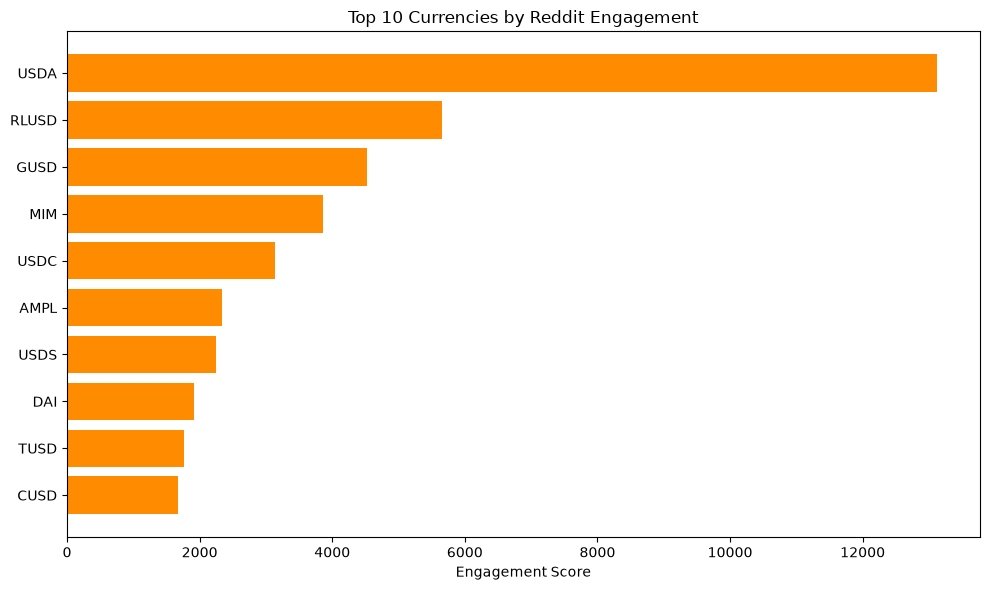

In [7]:
df_reddit['reddit_engagement'] = (
    df_reddit['data.ups'].fillna(0) +
    df_reddit['data.num_comments'].fillna(0) * 3
)

engagement = (
    df_reddit
    .groupby('symbol')['reddit_engagement']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("🏆 TOP 10 BY REDDIT ENGAGEMENT SCORE")
print("=" * 50)

for i, (symbol, score) in enumerate(engagement.items(), 1):
    print(f"{i:2d}. {symbol:10s} - {int(score):,}")

plt.figure(figsize=(10,6))
plt.barh(engagement.index, engagement.values, color='darkorange')
plt.gca().invert_yaxis()
plt.title("Top 10 Currencies by Reddit Engagement")
plt.xlabel("Engagement Score")
plt.tight_layout()
plt.show()

Cell 8: 📊 Engagement Quality

In [8]:
discussion_quality = (
    df_reddit
    .groupby('symbol')
    .agg(
        post_count=('data.id', 'count'),
        total_comments=('data.num_comments', 'sum')
    )
    .reset_index()
)

discussion_quality['comments_per_post'] = (
    discussion_quality['total_comments'] /
    discussion_quality['post_count']
)

top_quality = discussion_quality.sort_values(
    'comments_per_post', ascending=False
).head(10)

print("💎 TOP 10 BY DISCUSSION QUALITY")
print("=" * 50)

for i, row in enumerate(top_quality.itertuples(), 1):
    print(f"{i:2d}. {row.symbol:10s} - {row.comments_per_post:.1f} comments/post")

💎 TOP 10 BY DISCUSSION QUALITY
 1. USDA       - 16.3 comments/post
 2. RLUSD      - 9.8 comments/post
 3. MIM        - 8.9 comments/post
 4. GUSD       - 8.2 comments/post
 5. AMPL       - 6.1 comments/post
 6. USDS       - 5.8 comments/post
 7. USDC       - 5.5 comments/post
 8. DAI        - 4.4 comments/post
 9. TUSD       - 4.1 comments/post
10. USDE       - 3.2 comments/post


Cell 9: 🆚 Twitter vs Reddit Comparison

🐦 Loaded 3,918 Twitter records
🆚 TWITTER VS REDDIT – TOP 10
Crypto       Tweets    Posts      Likes    Upvotes
USDT            213      113       1061        137
RLUSD           198      115      14278       2290
USDS            193      100        216        514
MIM             188      100        808       1182
DAI             172      105        779        545
USDA             56      182        155       4195
USDC             99      138       2376        866
USDE            154       57       2022        225
EURA            200        6        112          9
YUSD            201        0       2388          0


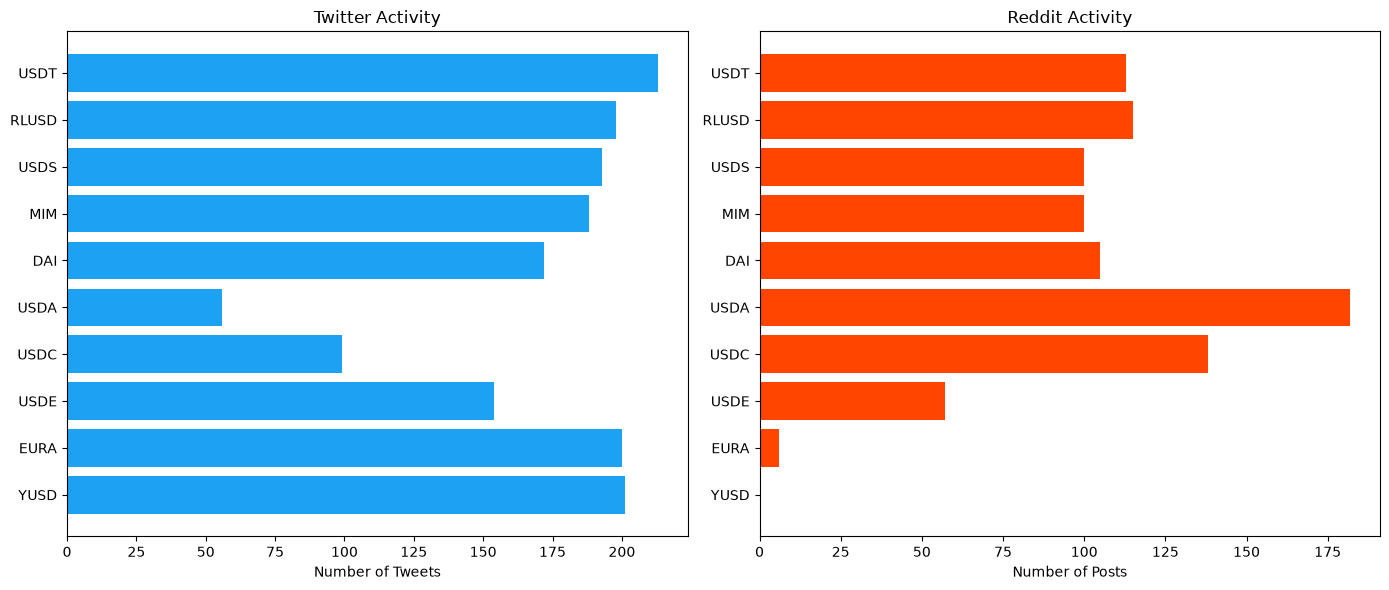


📊 Observation:
- Twitter = many short, quick-response pieces of content.
- Reddit = fewer articles, but deeper discussion.


In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# LOAD TWITTER JSON
# -----------------------------
with open('v4_x_tweets.json', 'r', encoding='utf-8') as f:
    twitter_raw = json.load(f)

print(f"🐦 Loaded {len(twitter_raw):,} Twitter records")

df_twitter = pd.json_normalize(twitter_raw)

# -----------------------------
# TWITTER ENGAGEMENT (handle all JSON shapes)
# -----------------------------
# Case A: nested public_metrics column (like Task 2)
if 'public_metrics' in df_twitter.columns:
    metrics_df = pd.json_normalize(df_twitter['public_metrics']).add_prefix('metric_')
    df_twitter_cmp = pd.concat(
        [df_twitter.drop(columns=['public_metrics']), metrics_df],
        axis=1
    )
else:
    df_twitter_cmp = df_twitter.copy()

# Resolve like/retweet column names (json_normalize may flatten to public_metrics.*)
def pick_col(df, candidates):
    for name in candidates:
        if name in df.columns:
            return name
    raise KeyError(f"None of {candidates} found. Available: {list(df.columns)[:20]}...")

likes_col = pick_col(df_twitter_cmp, [
    'metric_like_count',
    'public_metrics.like_count',
    'like_count',
])
rt_col = pick_col(df_twitter_cmp, [
    'metric_retweet_count',
    'public_metrics.retweet_count',
    'retweet_count',
])

# Ensure numeric before sum
df_twitter_cmp[likes_col] = pd.to_numeric(df_twitter_cmp[likes_col], errors='coerce').fillna(0)
df_twitter_cmp[rt_col] = pd.to_numeric(df_twitter_cmp[rt_col], errors='coerce').fillna(0)

twitter_engagement = (
    df_twitter_cmp
    .groupby('tokenSymbol')
    .agg(
        tweet_count=('id', 'count'),
        total_likes=(likes_col, 'sum'),
        total_retweets=(rt_col, 'sum'),
    )
    .reset_index()
    .rename(columns={'tokenSymbol': 'symbol'})
)

# -----------------------------
# REDDIT ENGAGEMENT (JSON)
# -----------------------------
reddit_engagement = (
    df_reddit
    .groupby('symbol')
    .agg(
        post_count=('data.id', 'count'),
        total_upvotes=('data.ups', 'sum'),
        total_comments=('data.num_comments', 'sum')
    )
    .reset_index()
)

# -----------------------------
# MERGE TWITTER + REDDIT
# -----------------------------
comparison = (
    twitter_engagement
    .merge(reddit_engagement, on='symbol', how='outer')
    .fillna(0)
)

# Total activity across platforms
comparison['total_activity'] = (
    comparison['tweet_count'] +
    comparison['post_count']
)

top_both = comparison.sort_values(
    'total_activity', ascending=False
).head(10)

# -----------------------------
# PRINT COMPARISON TABLE
# -----------------------------
print("🆚 TWITTER VS REDDIT – TOP 10")
print("=" * 75)
print(f"{'Crypto':<10} {'Tweets':>8} {'Posts':>8} {'Likes':>10} {'Upvotes':>10}")
print("=" * 75)

for _, row in top_both.iterrows():
    print(
        f"{row['symbol']:<10} "
        f"{int(row['tweet_count']):>8} "
        f"{int(row['post_count']):>8} "
        f"{int(row['total_likes']):>10} "
        f"{int(row['total_upvotes']):>10}"
    )

print("=" * 75)

# -----------------------------
# VISUAL COMPARISON
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Twitter
ax1.barh(top_both['symbol'], top_both['tweet_count'], color='#1DA1F2')
ax1.set_title('Twitter Activity')
ax1.set_xlabel('Number of Tweets')
ax1.invert_yaxis()

# Reddit
ax2.barh(top_both['symbol'], top_both['post_count'], color='#FF4500')
ax2.set_title('Reddit Activity')
ax2.set_xlabel('Number of Posts')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📊 Observation:")
print("- Twitter = many short, quick-response pieces of content.")
print("- Reddit = fewer articles, but deeper discussion.")

Cell 10: 📈 Summary Report

In [10]:
print("=" * 60)
print("📊 REDDIT ANALYSIS SUMMARY (JSON)")
print("=" * 60)
print()

# Basic stats
total_posts = len(df_reddit)
unique_symbols = df_reddit['symbol'].nunique()

print(f"Total Reddit posts analyzed : {total_posts:,}")
print(f"Unique currencies discussed: {unique_symbols}")

# Upvotes summary
if 'data.ups' in df_reddit.columns:
    total_upvotes = df_reddit['data.ups'].sum()
    avg_upvotes = df_reddit['data.ups'].mean()

    print(f"Total upvotes               : {int(total_upvotes):,}")
    print(f"Average upvotes per post    : {avg_upvotes:.1f}")

# Comments summary
if 'data.num_comments' in df_reddit.columns:
    total_comments = df_reddit['data.num_comments'].sum()
    avg_comments = df_reddit['data.num_comments'].mean()

    print(f"Total comments              : {int(total_comments):,}")
    print(f"Average comments per post   : {avg_comments:.1f}")

print()
print("✨ KEY FINDINGS:")

# Most posted
post_counts = df_reddit['symbol'].value_counts()
if len(post_counts) > 0:
    print(f"  🥇 Most posted on Reddit   : {post_counts.index[0]}")

# Most upvoted
if 'total_upvotes' in locals() and not total_upvotes == 0:
    top_upvoted = (
        df_reddit
        .groupby('symbol')['data.ups']
        .sum()
        .sort_values(ascending=False)
    )
    print(f"  ⬆️ Most upvoted currency   : {top_upvoted.index[0]}")

# Most commented
if 'total_comments' in locals() and not total_comments == 0:
    top_commented = (
        df_reddit
        .groupby('symbol')['data.num_comments']
        .sum()
        .sort_values(ascending=False)
    )
    print(f"  💬 Most commented currency : {top_commented.index[0]}")

# Highest engagement
if 'reddit_engagement' in df_reddit.columns:
    top_engagement = (
        df_reddit
        .groupby('symbol')['reddit_engagement']
        .sum()
        .sort_values(ascending=False)
    )
    print(f"  🏆 Highest engagement      : {top_engagement.index[0]}")

print()
print("=" * 60)

📊 REDDIT ANALYSIS SUMMARY (JSON)

Total Reddit posts analyzed : 1,797
Unique currencies discussed: 18
Total upvotes               : 14,359
Average upvotes per post    : 8.0
Total comments              : 9,927
Average comments per post   : 5.5

✨ KEY FINDINGS:
  🥇 Most posted on Reddit   : USDA
  ⬆️ Most upvoted currency   : USDA
  💬 Most commented currency : USDA
  🏆 Highest engagement      : USDA



Cell 11: 🎯 Your Achievement Summary

In [11]:
print("=" * 60)
print("🎉 AMAZING! YOU COMPLETED TASK 3 (JSON VERSION)!")
print("=" * 60)
print()

print("You just:")
print("  ✅ Analyzed Reddit data from JSON")
print("  ✅ Parsed nested Reddit structures")
print("  ✅ Counted upvotes and comments")
print("  ✅ Calculated Reddit engagement scores")
print("  ✅ Evaluated discussion quality")
print("  ✅ Compared Twitter vs Reddit (JSON)")
print("  ✅ Built multiple charts and summaries")
print()

print("🎓 You now understand:")
print("  • JSON data normalization")
print("  • Social media engagement metrics")
print("  • Community behavior on Reddit")
print("  • Cross-platform comparison (Twitter vs Reddit)")
print()

print("🚀 Ready for Task 4!")
print("Next step: Combine Reddit + Twitter into unified Social Analytics")
print("=" * 60)

🎉 AMAZING! YOU COMPLETED TASK 3 (JSON VERSION)!

You just:
  ✅ Analyzed Reddit data from JSON
  ✅ Parsed nested Reddit structures
  ✅ Counted upvotes and comments
  ✅ Calculated Reddit engagement scores
  ✅ Evaluated discussion quality
  ✅ Compared Twitter vs Reddit (JSON)
  ✅ Built multiple charts and summaries

🎓 You now understand:
  • JSON data normalization
  • Social media engagement metrics
  • Community behavior on Reddit
  • Cross-platform comparison (Twitter vs Reddit)

🚀 Ready for Task 4!
Next step: Combine Reddit + Twitter into unified Social Analytics
